# Idea : Maybe we can solve our convergence problems by having a different approach to the contrastive learning phase
1) Patient wise representations per modality (distinctively)
2) Learn the final representation by using self attention on embeddings paired with presence tokens (i.e learned tokens to represent the presence/absence of a modality)

## Why ?
1) Allows modality specific convergence while learning patient-wise embeddings. Modulo that we achieve convergence (i.e, unique representations per patients for each modality), the contatenated embedding will therefore also be unique which thus allows a unique representation of each patient in the dataset across modalities.
2) Because we would like to integrate across the different modalities (i.e. biological scales) we would like to slightly update the original representation concatenated from all 6 modalities with cross modality patterns => Self-Attention on the concatenated embeddings. However because having missing modalities is important to take into account, learning small embeddings that encode the presence/absence of each modality could help enrich the final representation.

## How ?
1) Compute 6 contrastive losses per batch, backpropagate gradient for each of them individually => 6 loss computations, 6 optimizers, 6 schedulers, 6 loss.backward()
2) Add an Attention block that takes as input the concatenated embedding and output the cross-modality enriched representation
   + Have another Attention block that takes the missing modalities vector ([1,0,0,1,1,1]) as input and output a representation of the modality statuses for the patient (a dense layer might be necessary prior to that to encode it instead of simply having binary signal as input to the attention layer)
   + Have a final attention mechanism that queries the missing modality representation with respect to the cross-modality representation in order to integrate the status of each modality into the final embedding of the patient.
     
Note: The 2) point is done by the clinical linkage phase (i.e. predictive learning phase). Thus we need:
- The MultiModalEncoder
- The PredictiveHead = (Attention blocks + MLP per task)

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

['/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python310.zip', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/lib-dynload', '', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages', '/home/sagemaker-user/gbm_hackathon']


In [2]:
%load_ext autoreload
%autoreload 2

from gbmhackathon.training.predictive import *
from gbmhackathon.models.mme import MultiModalEncoder, ClinicalLinkageModule, concat_modality_embeddings
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction, RankMe, make_patient_map, RegularizationModule
from gbmhackathon.utils.module_functions import instantiate
from gbmhackathon.training.loops import modality_wise_contrastive_learning, new_predictive_learning
from gbmhackathon.utils.analysis import *
from gbmhackathon.viz.viz_experiment import *
from gbmhackathon.s3_loader import load_s3

import os
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To investigate gradients
from torchviz import make_dot

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam

In [3]:
torch.set_num_threads(16)
torch.get_num_threads()

16

In [4]:
device = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

In [5]:
name_emb_dict = {"hne":"embeddings_HnE_OptimusH0.pkl",
# "spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-05-25_14-36_new_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl",
"bulk":"2025-05-03_10-15_bulk_emb_V1.pkl",
"scRNA":"2025-05-04_02-35_scRNA_emb_V1.pkl"}
pkl_storage_folder = "embedding_V1"

In [6]:
dataset = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, device=device, dropout=1.0)
print(f"Dataset size: {len(dataset)}")
BATCH_SIZE = 582
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset.device))

cas 2 : device reconnu : cpu 
Using device: cpu
By keeping 100.00% of dropout augmented samples we went from:
468 dropout samples (80.41% dropout in dataset) -- to --> 468 dropout samples (80.41% dropout in dataset)
Dataset size: 582


In [7]:
# Batch of all true samples (no dropout augmented samples)
batch_all = [dataset.__getitem__(idx) for idx in dataset.ind2patient if 'd' not in dataset.ind2patient[idx]]
batch_all = collate_predictive(batch_all)

In [8]:
raw_emb = next(iter(dataloader))[2]
inpute_size_dict = {}
for mod in raw_emb.keys():
    print(mod, raw_emb[mod].size())
    inpute_size_dict[mod] = raw_emb[mod].size(1)

hne torch.Size([582, 1536])
clinical torch.Size([582, 20])
wes torch.Size([582, 1790])
bulk torch.Size([582, 3072])
scRNA torch.Size([582, 3072])


In [9]:
patient_map = make_patient_map(dataset)

In [10]:
def adapt_base_config(base_cfg, input_size):
    base_copy = deepcopy(base_cfg)
    base_copy["layers"] = [input_size] + base_copy["layers"]
    return base_copy

In [11]:
out = 32
norm_fn = nn.BatchNorm1d
base_cfg = {"layers": [512,128,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}

hne_cfg = {"layers": [512,128,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}

clinical_cfg = {"layers": [256,128,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}

wes_cfg = {"layers": [512,128,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}

rna_cfg = {"layers": [1024,256,out],
        "dropout": 0.3,
        "act_fn":nn.GELU,
        "norm_layer":norm_fn,
        "device":device}


hne_cfg = adapt_base_config(hne_cfg, inpute_size_dict["hne"])
#spatial_cfg = adapt_base_config(small_capacity_cfg, inpute_size_dict["spatial"])
clinical_cfg = adapt_base_config(clinical_cfg, inpute_size_dict["clinical"])
wes_cfg = adapt_base_config(wes_cfg, inpute_size_dict["wes"])
bulk_cfg = adapt_base_config(rna_cfg, inpute_size_dict["bulk"])
sc_cfg = adapt_base_config(rna_cfg, inpute_size_dict["scRNA"])

In [12]:
mme_bulk_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": bulk_cfg}

mme_hne_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": hne_cfg}

mme_sc_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": sc_cfg}

mme_wes_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": wes_cfg}

mme_clinical_cfg = {"net_type": "mlp",
                "device": device,
                "net_config": clinical_cfg}

In [13]:
mme_cfg = {"hne_cfg":mme_hne_cfg, 
           "clinical_cfg":mme_clinical_cfg, 
           "wes_cfg":mme_wes_cfg, 
           #"spatial_cfg":mme_spatial_cfg,
           "bulk_cfg":mme_bulk_cfg,
          "sc_cfg":mme_sc_cfg}

In [14]:
base_head_cfg = {"layers": [out*len(mme_cfg),1024,512,5],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.ReLU, nn.ReLU, None],
        "norm_layer":norm_fn,
        "device":device}
head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": base_head_cfg}

In [28]:
regularizer_cfg = {"reg_coeff":0.1,
        # "use_invariance":False,
        # "inv_coeff":25.0,
        "use_variance":True,
        "var_coeff":25.0,
        "use_covariance":True,
        "cov_coeff":1.0,
        "var_gamma":1.0,
        "var_eps":1e-4,
        # "use_soft_orth":False,
        # "so_coeff":1.0,
        # "use_srip":False,
        # "srip_coeff":1.0,
        # "srip_iters":1,
}

In [49]:
mme = instantiate(mme_cfg,MultiModalEncoder)

EPOCHS_I = 10
base_lr_I = 1e-3
eta_min_coef = 0.05
scheduler_I_class = torch.optim.lr_scheduler.CosineAnnealingLR
scheduler_I_cfg = {"T_max":EPOCHS_I,
                  "eta_min":"dynamic"}

contrastive_loss_cfg = {"modalities":list(name_emb_dict.keys()),
                        "patient_map":patient_map,
                        "temperature":0.05,
                        "similarity":'nt-xent',
                        "use_all_positives":False,
                        "alpha":0,
                        "bound":-50,
                        "slope":0.1,
                        "rate":-5,
                        "warn":False,
                       "smoothing_func":False}

# Optimization for Phase I
optimizer_I = Adam(mme.parameters(), lr=base_lr_I)
scheduler_I_cfg["optimizer"] = optimizer_I
if "eta_min" in scheduler_I_cfg.keys():
    if scheduler_I_cfg["eta_min"] == "dynamic":
        scheduler_I_cfg["eta_min"] = eta_min_coef * base_lr_I
scheduler_I = instantiate(scheduler_I_cfg, scheduler_I_class)

contrastive_loss_fn = instantiate(contrastive_loss_cfg, RegularizedInfoNCELoss)

modalities = next(iter(dataloader))[2].keys()
    
# A contrastive loss module per modality
modality_contrastive_loss_fn = {}
for modality in modalities:
    contrastive_loss_cfg_mod = contrastive_loss_cfg.copy()
    contrastive_loss_cfg_mod['modalities'] = [modality]
    modality_contrastive_loss_fn[modality] = instantiate(contrastive_loss_cfg_mod, RegularizedInfoNCELoss)

# An optimizer per modality
modality_optimizers = {modality:Adam(mme.modality_net_map[modality].parameters(), lr=base_lr_I) for modality in modalities}

# A scheduler per modality
modality_schedulers = {}
for modality in modalities:
    # Same schedule for all modalities for now, but it can be configurable
    scheduler_cfg = scheduler_I_cfg.copy()
    scheduler_cfg["optimizer"] = modality_optimizers[modality]
    if "eta_min" in scheduler_I_cfg.keys():
        if scheduler_cfg["eta_min"] == "dynamic":
            scheduler_cfg["eta_min"] = eta_min_coef * base_lr_I
    modality_schedulers[modality] = instantiate(scheduler_cfg, scheduler_I_class)

# A regularization method per modality
regularizer_dict = {}
for modality in modalities:
    regularizer_dict[modality] = instantiate(regularizer_cfg, RegularizationModule)

{'net_type': 'mlp', 'device': 'cpu', 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': <class 'torch.nn.modules.activation.GELU'>, 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cpu'}}
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found


EPOCH 1 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.4613
EPOCH 2 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.9597
EPOCH 3 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.6793
EPOCH 4 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.6709
EPOCH 5 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.5838
EPOCH 6 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.4194
EPOCH 7 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.2624
EPOCH 8 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.1814
EPOCH 9 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.1434
EPOCH 10 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.0742


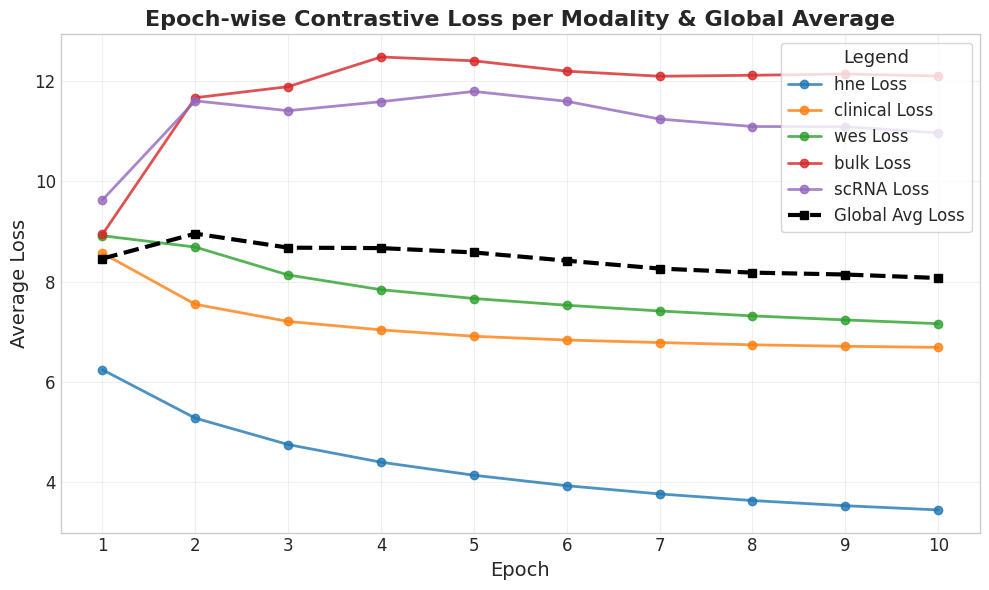

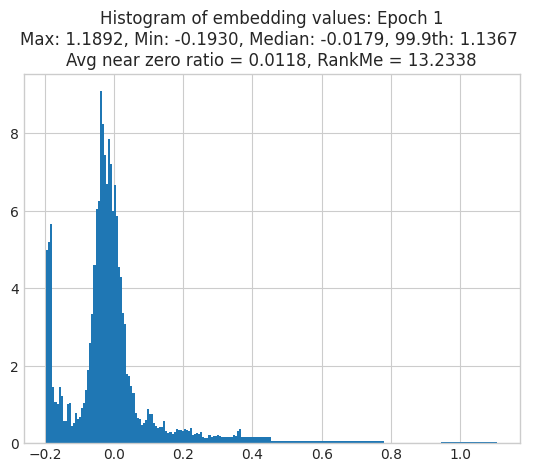

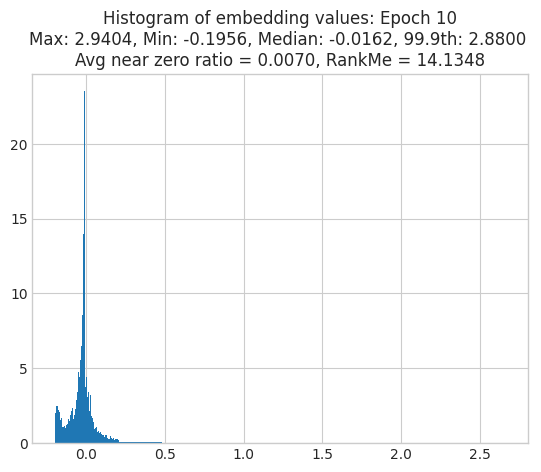

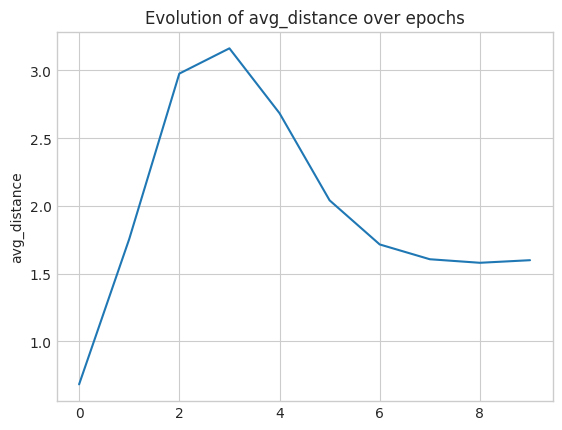

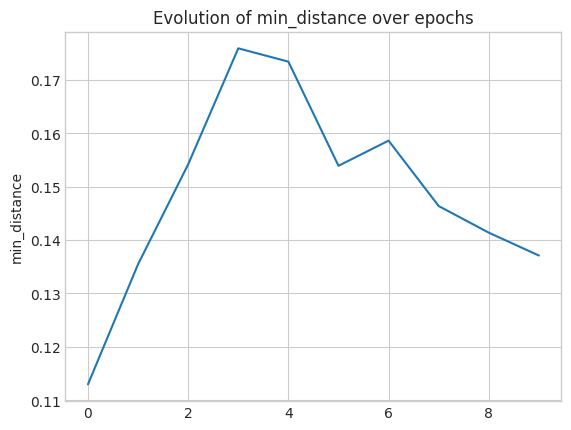

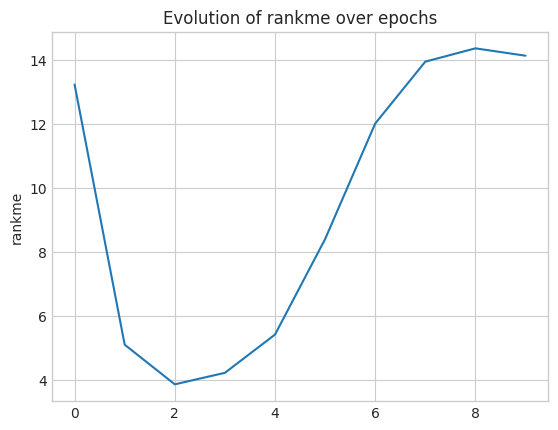

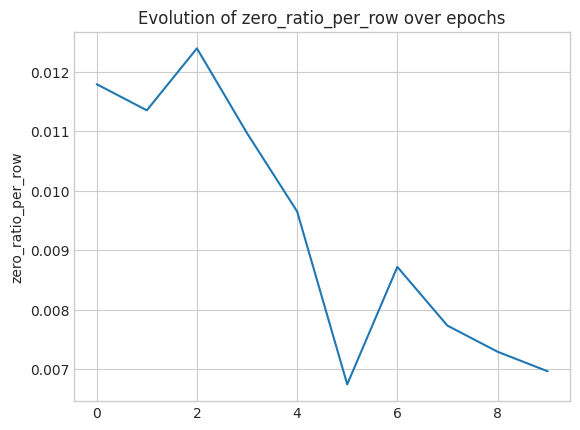

Saved animation to emb_mme_animation.gif
Saved animation to emb_by_modality_animation.gif


In [ ]:
modality_wise_contrastive_learning(mme, 
                                   dataloader, 
                                   EPOCHS_I, 
                                   1e-3, 
                                   modality_optimizers, 
                                   modality_contrastive_loss_fn, 
                                   modality_schedulers,
                                   regularizer_dict,
                                   batch_all=batch_all,
                                   make_gifs=True,
                                   analyze_emb=True)

In [34]:
reg_head_cfg = {"layers": [out*len(mme_cfg),512,256,1],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.GELU, nn.GELU, None],
        "norm_layer":norm_fn,
        "device":device}
binary_clf_head_cfg = {"layers": [out*len(mme_cfg),512,256,2],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.GELU, nn.GELU, None],
        "norm_layer":norm_fn,
        "device":device}
multi_clf_head_cfg = {"layers": [out*len(mme_cfg),512,256,3],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.GELU, nn.GELU, None],
        "norm_layer":norm_fn,
        "device":device}

In [35]:
os_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
pfs_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
diameter_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
recurrency_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": binary_clf_head_cfg}
mgmt_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": multi_clf_head_cfg}

In [36]:
# ATTENTION !!!! MUST BE THIS EXACT ORDER FOR PREDICTIVE TASKS: 
# ['os_years', 'pfs_years', 'largest_diameter_of_the_primary_tumour_mm_duplicated_0', 'recurrent_sample']
# OR ['os_years', 'pfs_years', 'recurrent_sample', 'mgmt_promoter_methylation'] if using latest targets
predictive_cfg = {"heads_configs":{"os": os_head_cfg,
                  "pfs": pfs_head_cfg,
                  "diameter": diameter_head_cfg,
                  "recurrency":recurrency_head_cfg,
                  "mgmt":mgmt_head_cfg}}
refinement_cfg = {"emb_size": out*len(mme_cfg),
                "cross_modality_heads": 4,
                "avail_mods_len":5,
                "avail_mods_dense_size": 32,
                "avail_mods_heads": 1,
                "act_fn": nn.GELU,
                "dropout": 0.3,
                "device": device}
clf_targets = ['recurrency', 'mgmt']
clf_targets_dict = {'recurrency':2, 'mgmt':3}

In [37]:
clm = ClinicalLinkageModule(refinement_cfg=refinement_cfg,
                            predictive_cfg=predictive_cfg)

Using device: cpu
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found


In [38]:
EPOCHS_II = 200
base_lr_II = 1e-3
scheduler_II_class = torch.optim.lr_scheduler.CosineAnnealingLR
scheduler_II_cfg = {"T_max":EPOCHS_II,
                    "eta_min":"dynamic"}
# Optimization for Phase II
optimizer_II = Adam(clm.parameters(), lr=base_lr_II)
scheduler_II_cfg["optimizer"] = optimizer_II
if "eta_min" in scheduler_II_cfg.keys():
    if scheduler_II_cfg["eta_min"] == "dynamic":
        scheduler_II_cfg["eta_min"] = eta_min_coef * base_lr_II
scheduler_II = instantiate(scheduler_II_cfg, scheduler_II_class)

EPOCH 1 TOTAL LOSS: 7.1570
EPOCH 2 TOTAL LOSS: 5.1324
EPOCH 3 TOTAL LOSS: 4.9687
EPOCH 4 TOTAL LOSS: 4.6904
EPOCH 5 TOTAL LOSS: 4.5795
EPOCH 6 TOTAL LOSS: 4.4140
EPOCH 7 TOTAL LOSS: 4.3951
EPOCH 8 TOTAL LOSS: 4.3357
EPOCH 9 TOTAL LOSS: 4.1805
EPOCH 10 TOTAL LOSS: 4.1393
EPOCH 11 TOTAL LOSS: 4.4434
EPOCH 12 TOTAL LOSS: 4.6299
EPOCH 13 TOTAL LOSS: 4.6619
EPOCH 14 TOTAL LOSS: 4.7269
EPOCH 15 TOTAL LOSS: 4.5873
EPOCH 16 TOTAL LOSS: 4.2919
EPOCH 17 TOTAL LOSS: 4.1766
EPOCH 18 TOTAL LOSS: 4.0516
EPOCH 19 TOTAL LOSS: 4.2511
EPOCH 20 TOTAL LOSS: 4.2850
EPOCH 21 TOTAL LOSS: 4.3792
EPOCH 22 TOTAL LOSS: 4.5287
EPOCH 23 TOTAL LOSS: 4.7403
EPOCH 24 TOTAL LOSS: 4.7619
EPOCH 25 TOTAL LOSS: 4.7688
EPOCH 26 TOTAL LOSS: 4.6763
EPOCH 27 TOTAL LOSS: 4.6436
EPOCH 28 TOTAL LOSS: 4.5013
EPOCH 29 TOTAL LOSS: 4.4942
EPOCH 30 TOTAL LOSS: 4.5841
EPOCH 31 TOTAL LOSS: 4.4232
EPOCH 32 TOTAL LOSS: 4.4029
EPOCH 33 TOTAL LOSS: 4.4144
EPOCH 34 TOTAL LOSS: 4.3603
EPOCH 35 TOTAL LOSS: 4.3724
EPOCH 36 TOTAL LOSS: 4.1987
E

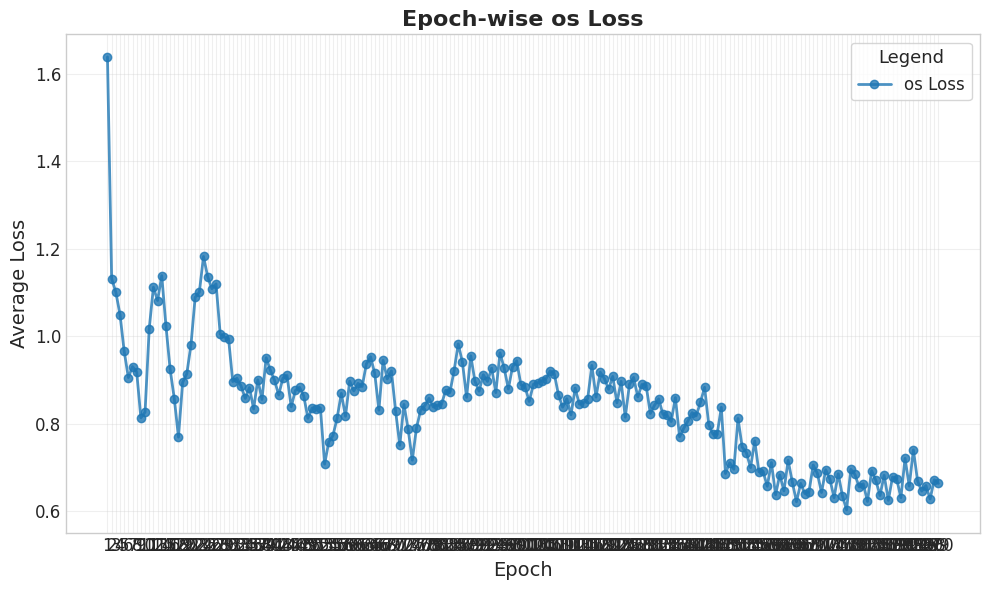

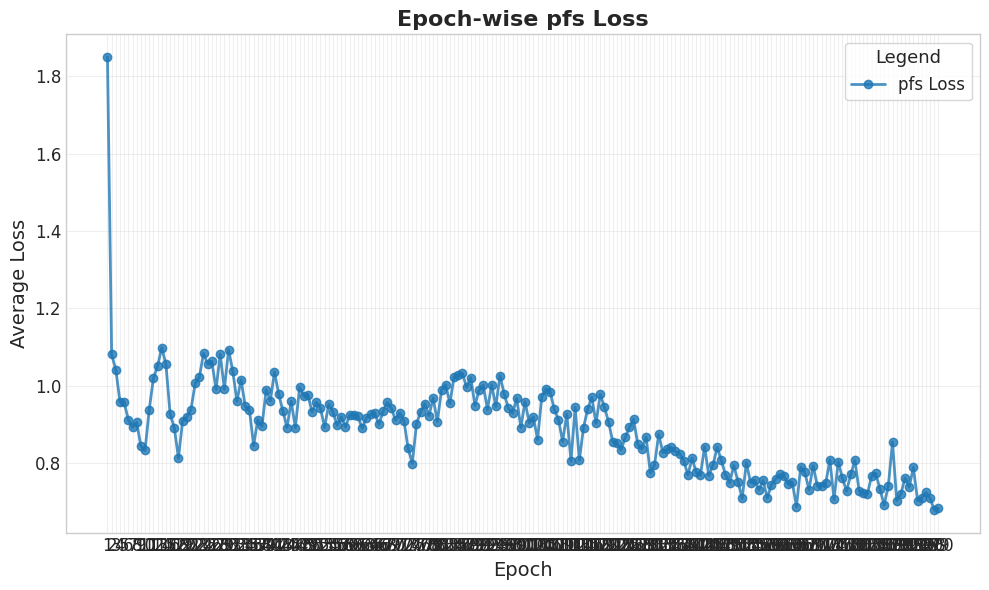

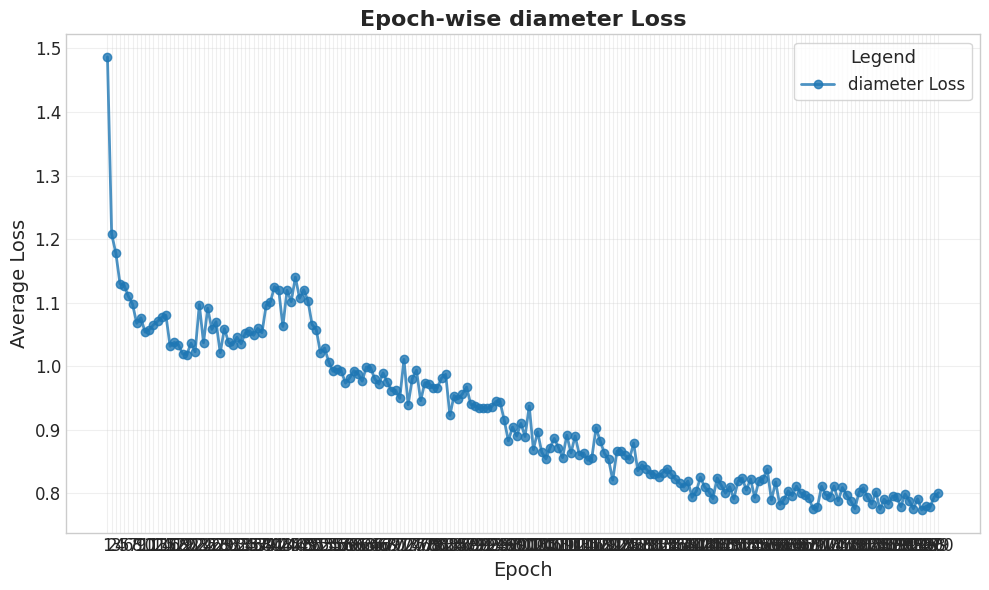

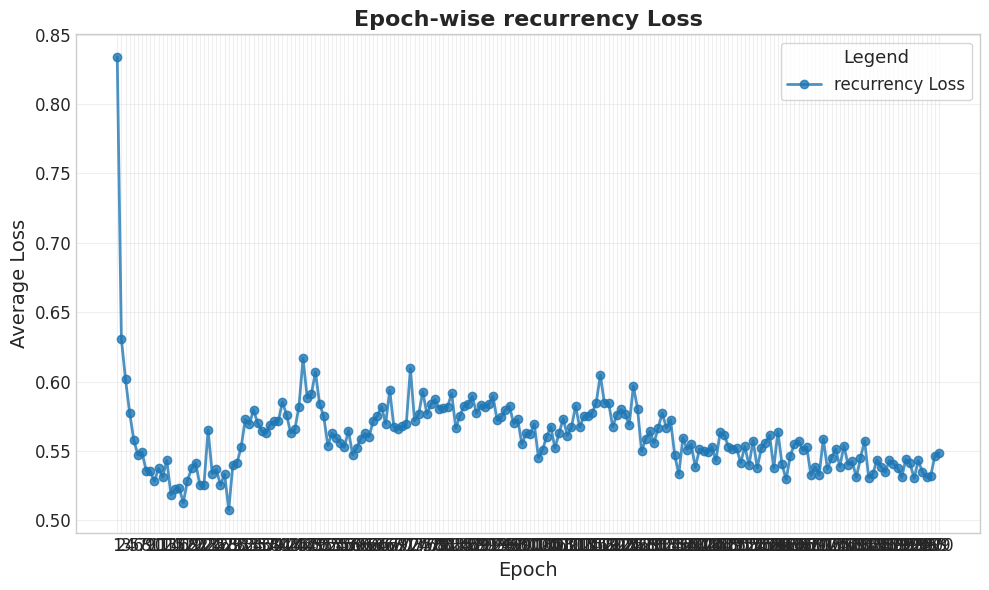

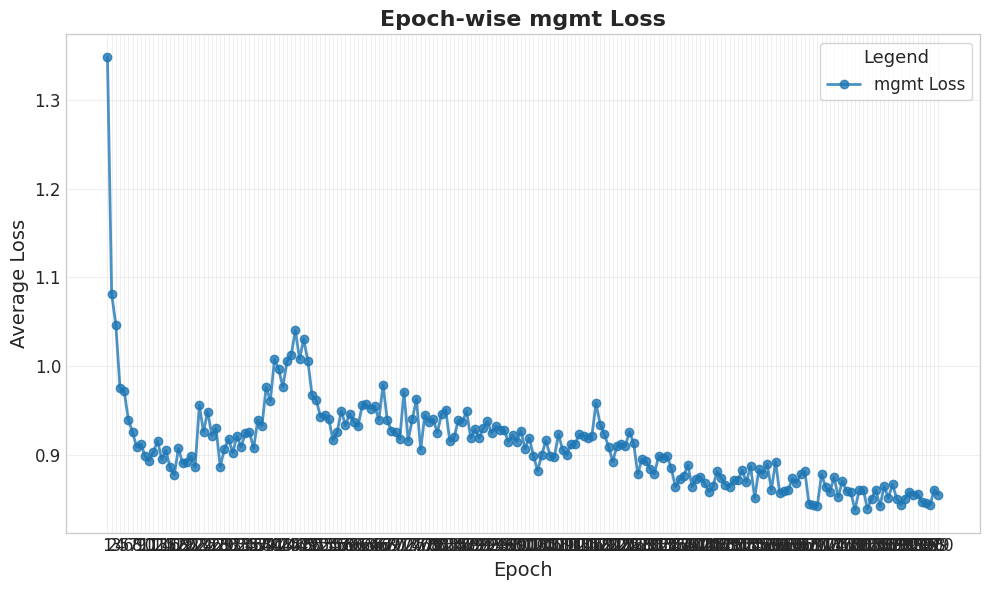

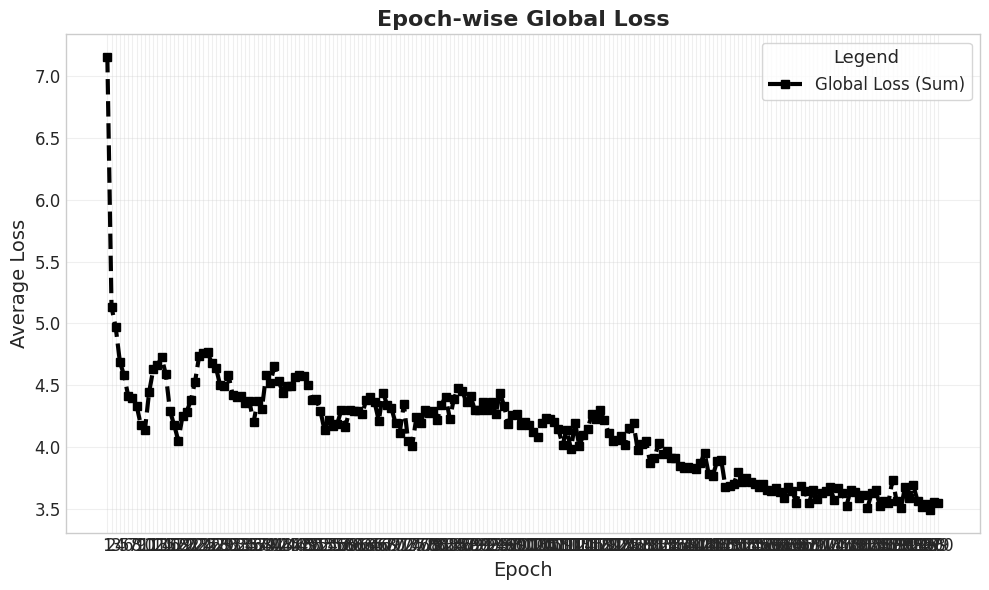

In [39]:
new_predictive_learning(mme, clm, 
                          dataloader,
                          EPOCHS_II, 
                          base_lr_II, 
                          optimizer_II,
                          scheduler_II,
                          clf_targets_dict,
                          reg_loss_fn = nn.MSELoss(),
                          clf_loss_fn = nn.CrossEntropyLoss(),
                          batch_all=batch_all,
                          make_gifs=False,
                          )

In [40]:
mme_embeddings_dict, patient_embeddings = new_framework_inference(batch_all, mme, clm)
mme_embeddings = concat_modality_embeddings(mme_embeddings_dict)

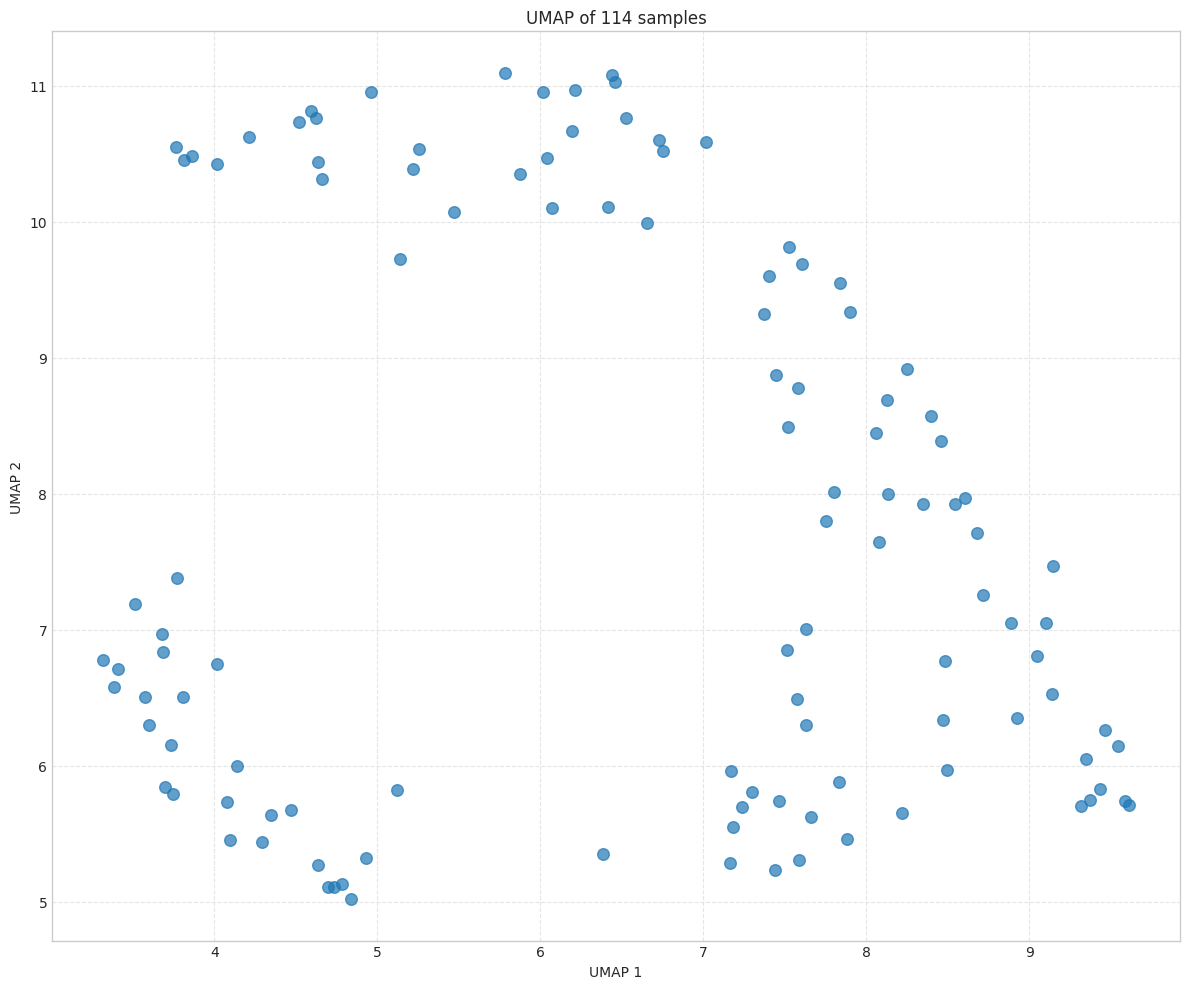

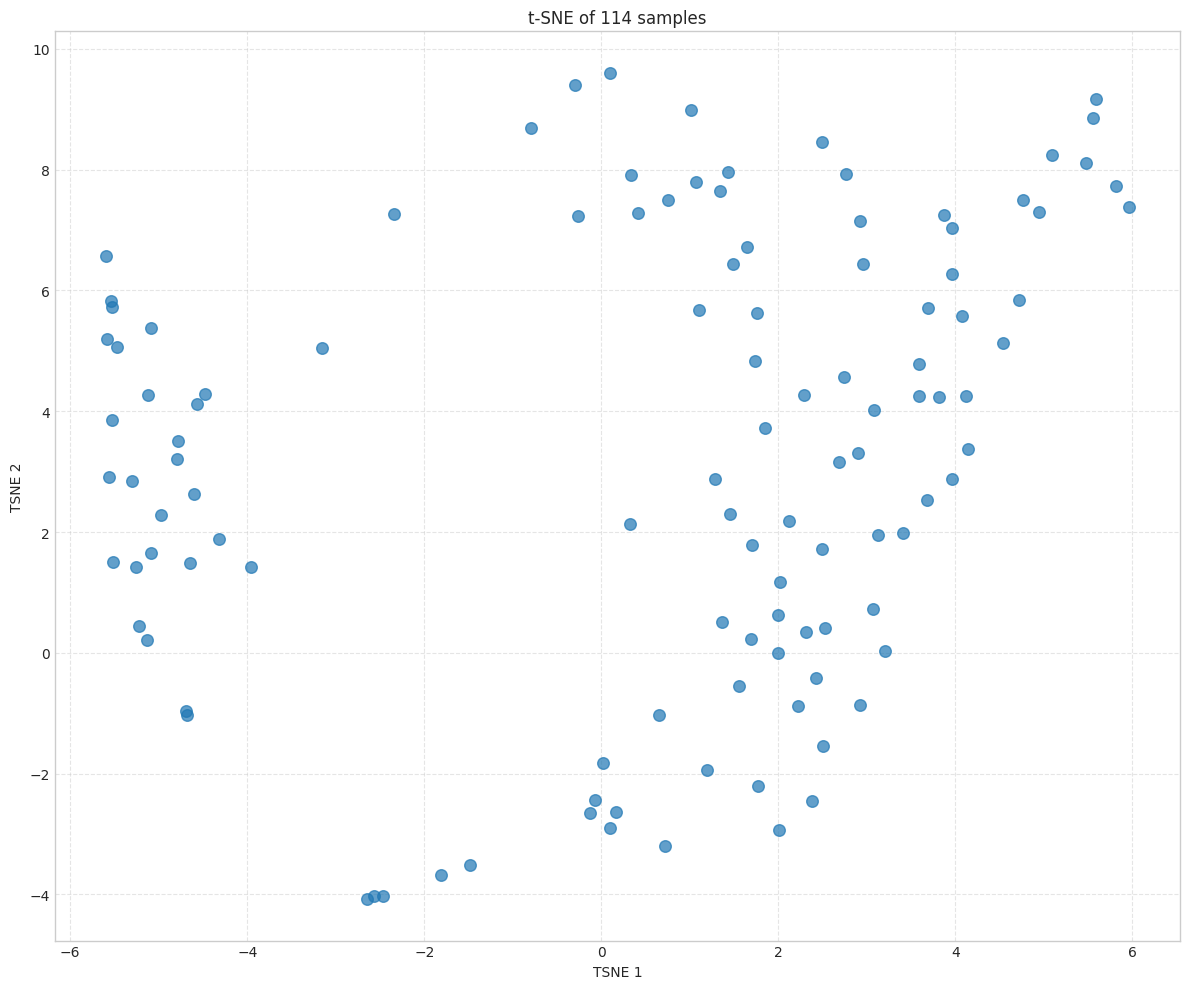

In [41]:
# Inference on all original patient samples after Multi Modal Encoding
visualize_inference(mme_embeddings, visualizers=['umap', 'tsne'])

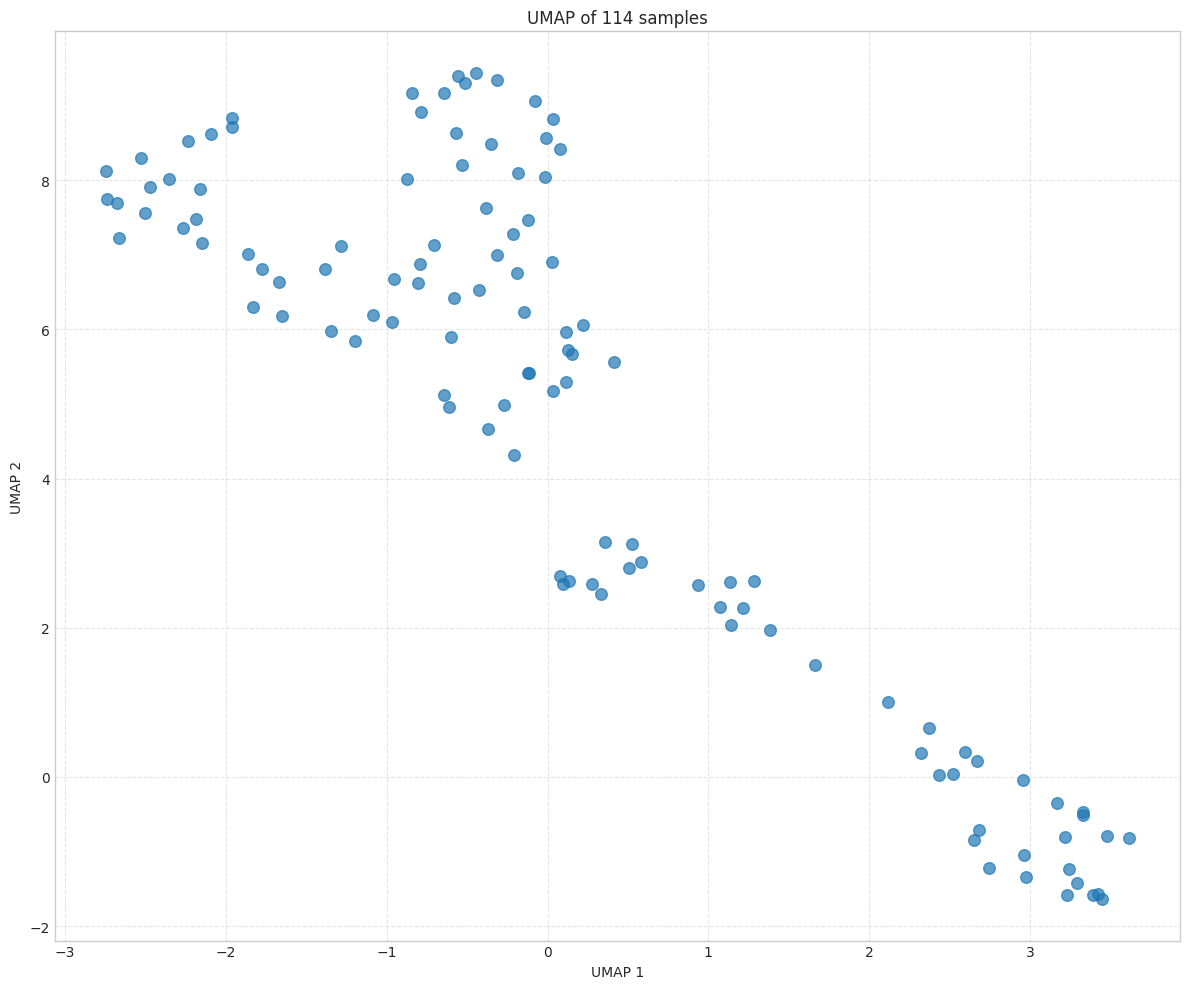

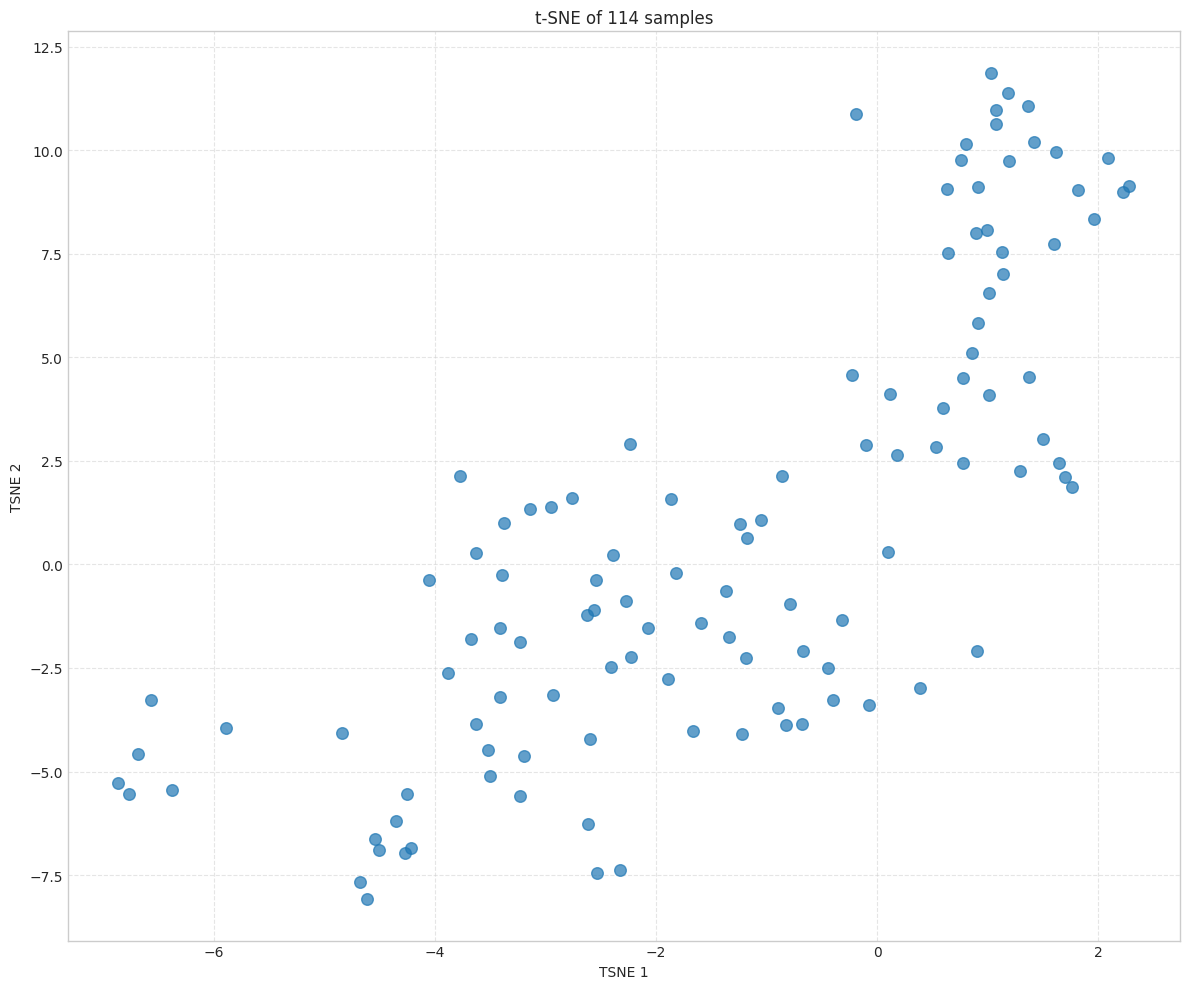

In [42]:
# Inference on all original patient samples (final patient representations)
visualize_inference(patient_embeddings, visualizers=['umap', 'tsne'])

Best Silouhette Score :0.31828537583351135


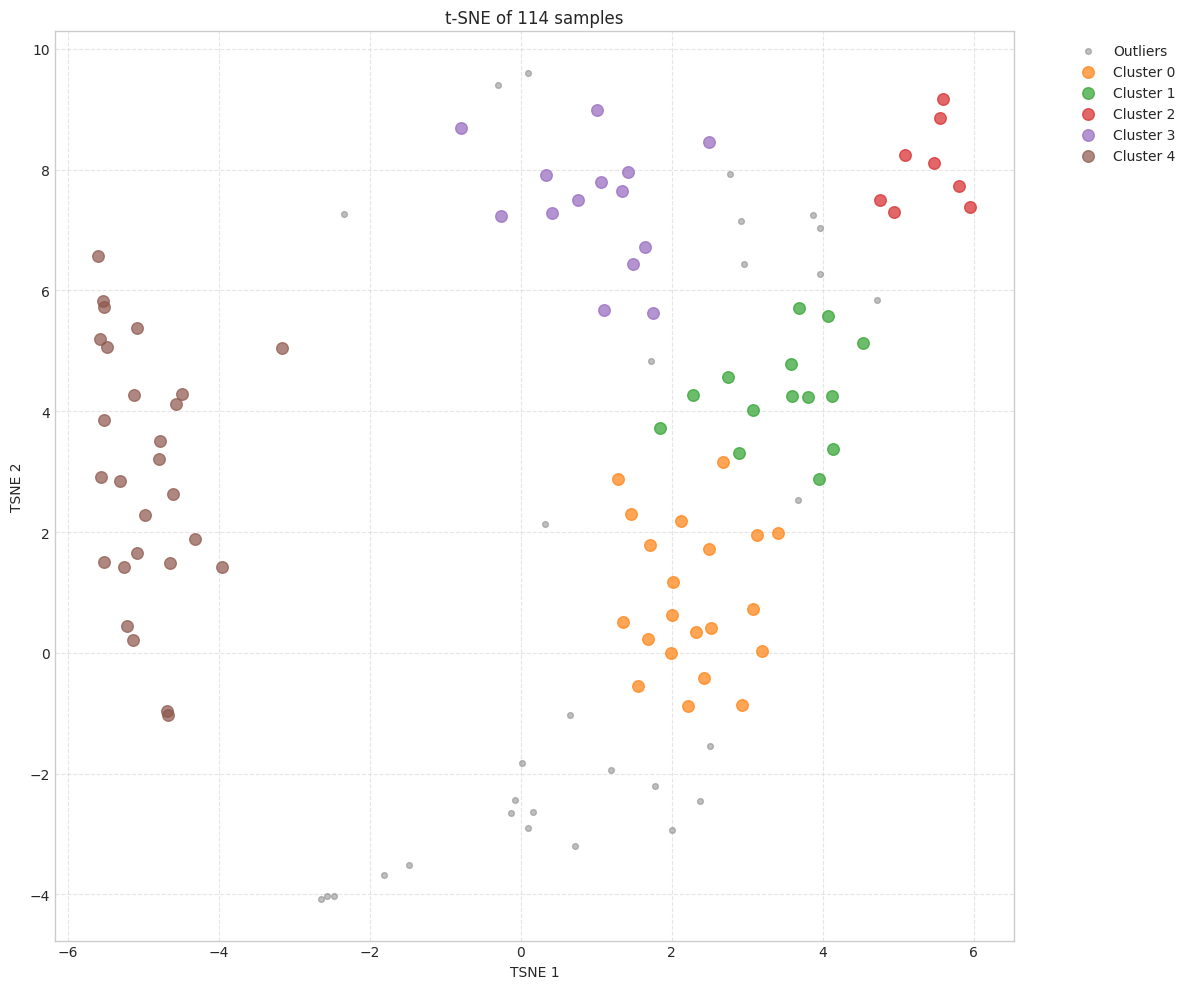

In [43]:
visualize_embeddings(mme_embeddings, 'tsne', cluster_method='optics', return_fig=True)
plt.show()

Best Silouhette Score :0.4680006802082062


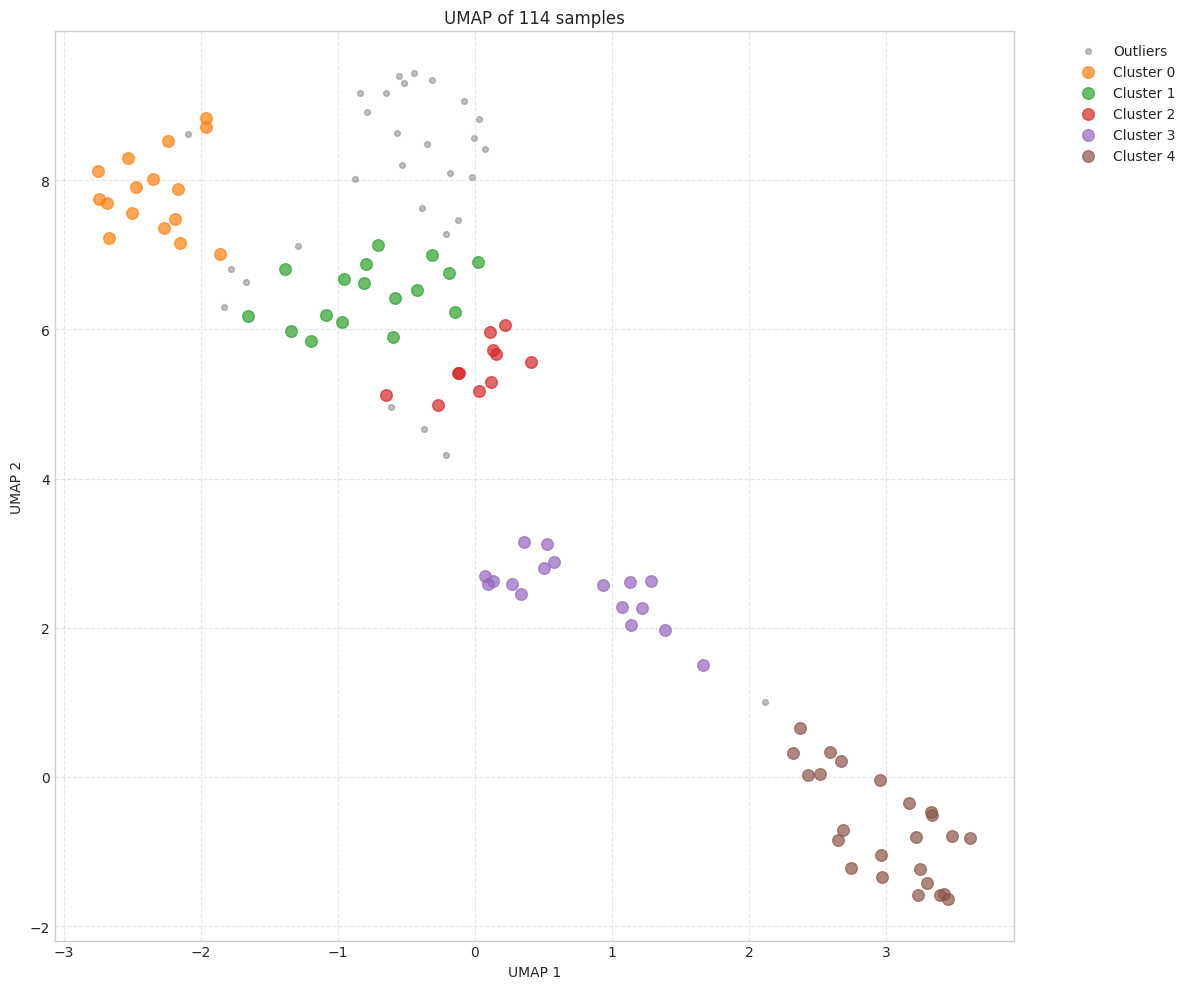

In [44]:
visualize_embeddings(patient_embeddings, 'umap', cluster_method='optics', return_fig=True)
plt.show()

# **Saving trained models**

In [26]:
from gbmhackathon.utils.model_saving import save_model, load_model

## To see what we saved

In [27]:
mme

MultiModalEncoder(
  (modality_net_map): ModuleDict(
    (hne): ModalityEncoder(
      (net): MLP(
        (network_layers): ModuleList(
          (0): Linear(in_features=1536, out_features=512, bias=True)
          (1): Dropout(p=0.3, inplace=False)
          (2): GELU(approximate='none')
          (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (4): Linear(in_features=512, out_features=128, bias=True)
          (5): Dropout(p=0.3, inplace=False)
          (6): GELU(approximate='none')
          (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (8): Linear(in_features=128, out_features=32, bias=True)
          (9): GELU(approximate='none')
          (10): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
    )
    (scRNA): ModalityEncoder(
      (net): MLP(
        (network_layers): ModuleList(
          (0): Linear(in_features=3072, out_feature

In [28]:
mme_path, mme_cfg_path = save_model(mme, '../saved_models/new_framework_mme.ckpt')


Model saved at path: /home/sagemaker-user/gbm_hackathon/saved_models/new_framework_mme.ckpt
Model config saved at cfg_path: /home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_framework_mme.ckpt
You can load it by doing loaded_model = load_model(model_class, path, cfg_path, device)


In [29]:
clm

ClinicalLinkageModule(
  (refinement_block): RefinementBlock(
    (cross_modality_enricher): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=160, out_features=160, bias=True)
    )
    (cross_modality_enricher_proj): Sequential(
      (0): Linear(in_features=160, out_features=1024, bias=True)
      (1): GELU(approximate='none')
      (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Linear(in_features=1024, out_features=160, bias=True)
      (4): GELU(approximate='none')
      (5): BatchNorm1d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (available_modality_linear_encoder): Sequential(
      (0): Linear(in_features=5, out_features=32, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=32, out_features=5, bias=True)
    )
    (available_modality_attn_encoder): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=5, out

In [30]:
clm_path, clm_cfg_path = save_model(clm, '../saved_models/new_framework_clm.ckpt')


Model saved at path: /home/sagemaker-user/gbm_hackathon/saved_models/new_framework_clm.ckpt
Model config saved at cfg_path: /home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_framework_clm.ckpt
You can load it by doing loaded_model = load_model(model_class, path, cfg_path, device)


## Load models back again just to check we retrieve the expected objects

In [31]:
loaded_mme = load_model(MultiModalEncoder, mme_path, mme_cfg_path, device, training=False)

{'net_type': 'mlp', 'device': 'cpu', 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': <class 'torch.nn.modules.activation.GELU'>, 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cpu'}}
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found

Model succesfully loaded. Model currently in inference mode.


In [32]:
loaded_mme

MultiModalEncoder(
  (modality_net_map): ModuleDict(
    (hne): ModalityEncoder(
      (net): MLP(
        (network_layers): ModuleList(
          (0): Linear(in_features=1536, out_features=512, bias=True)
          (1): Dropout(p=0.3, inplace=False)
          (2): GELU(approximate='none')
          (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (4): Linear(in_features=512, out_features=128, bias=True)
          (5): Dropout(p=0.3, inplace=False)
          (6): GELU(approximate='none')
          (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (8): Linear(in_features=128, out_features=32, bias=True)
          (9): GELU(approximate='none')
          (10): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
    )
    (scRNA): ModalityEncoder(
      (net): MLP(
        (network_layers): ModuleList(
          (0): Linear(in_features=3072, out_feature

In [33]:
loaded_clm = load_model(ClinicalLinkageModule, clm_path, clm_cfg_path, device, training=False)

Using device: cpu
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found

Model succesfully loaded. Model currently in inference mode.


In [34]:
loaded_clm

ClinicalLinkageModule(
  (refinement_block): RefinementBlock(
    (cross_modality_enricher): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=160, out_features=160, bias=True)
    )
    (cross_modality_enricher_proj): Sequential(
      (0): Linear(in_features=160, out_features=1024, bias=True)
      (1): GELU(approximate='none')
      (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Linear(in_features=1024, out_features=160, bias=True)
      (4): GELU(approximate='none')
      (5): BatchNorm1d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (available_modality_linear_encoder): Sequential(
      (0): Linear(in_features=5, out_features=32, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=32, out_features=5, bias=True)
    )
    (available_modality_attn_encoder): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=5, out